# Task 1: Data Loading, Merging & Deep Exploration

## Objective

The objective of this task is to load the datasets, inspect their structure, preprocess the date columns, engineer time-based features, aggregate sales at different time levels, and perform exploratory analysis to answer key business questions.

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [19]:
sales_df = pd.read_csv("train.csv.zip")
vg_df = pd.read_csv("vgsales.csv.zip")

In [20]:
print("Superstore Dataset")
display(sales_df.head())

print("\nVideo Game Sales Dataset")
display(vg_df.head())

Superstore Dataset


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680



Video Game Sales Dataset


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [21]:
print("Superstore Dataset Shape :", sales_df.shape)
print("Video Game Dataset Shape :", vg_df.shape)

Superstore Dataset Shape : (9800, 18)
Video Game Dataset Shape : (16598, 11)


In [22]:
print("Superstore Columns")

print(sales_df.columns)

print("\nVideo Game Columns")

print(vg_df.columns)

Superstore Columns
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Video Game Columns
Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')


In [23]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [24]:
vg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [25]:
sales_df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [26]:
vg_df.describe(include="all")

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16598,16598,16327.000000,16598,16540,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
unique,NaN,11493,31,NaN,12,578,NaN,NaN,NaN,NaN,NaN
top,NaN,Need for Speed: Most Wanted,DS,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,2163,NaN,3316,1351,NaN,NaN,NaN,NaN,NaN
mean,8300.605254,NaN,NaN,2006.406443,NaN,NaN,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,NaN,NaN,5.828981,NaN,NaN,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,NaN,NaN,2007.000000,NaN,NaN,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,NaN,NaN,2010.000000,NaN,NaN,0.240000,0.110000,0.040000,0.040000,0.470000


In [27]:
print("Superstore Missing Values")

display(sales_df.isnull().sum())

print("\nVideo Game Missing Values")

display(vg_df.isnull().sum())

Superstore Missing Values


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0



Video Game Missing Values


,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [28]:
print("Superstore Duplicate Rows :", sales_df.duplicated().sum())

print("Video Game Duplicate Rows :", vg_df.duplicated().sum())

Superstore Duplicate Rows : 0
Video Game Duplicate Rows : 0


In [29]:
sales_df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [30]:
vg_df.dtypes

,0
Rank,int64
Name,object
Platform,object
Year,float64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64


### Observations

- Both datasets were successfully loaded into the notebook.
- The Superstore dataset contains sales, shipping, customer, and product-related information.
- The Video Game Sales dataset will be used later for multi-source analysis.
- Initial inspection helps identify missing values, duplicate records, and incorrect data types before preprocessing.

## 1.11 Date Parsing

The **Order Date** and **Ship Date** columns are converted from object type to datetime format. This enables time-series analysis and allows extraction of useful date-related features.

In [34]:
sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"], format="%d/%m/%Y")
sales_df["Ship Date"] = pd.to_datetime(sales_df["Ship Date"], format="%d/%m/%Y")

In [35]:
sales_df[["Order Date", "Ship Date"]].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


## 1.12 Time Feature Engineering

Time-based features are extracted from the **Order Date** to support exploratory analysis, forecasting models, and seasonality detection.

In [36]:
sales_df["Year"] = sales_df["Order Date"].dt.year

In [37]:
sales_df["Month"] = sales_df["Order Date"].dt.month

In [38]:
sales_df["Week_Number"] = sales_df["Order Date"].dt.isocalendar().week.astype(int)

In [39]:
sales_df["Day_of_Week"] = sales_df["Order Date"].dt.day_name()

In [40]:
sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

In [41]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

In [42]:
sales_df["Season"] = sales_df["Month"].apply(get_season)

In [43]:
sales_df[[
    "Order Date",
    "Year",
    "Month",
    "Week_Number",
    "Day_of_Week",
    "Quarter",
    "Season"
]].head()

,Order Date,Year,Month,Week_Number,Day_of_Week,Quarter,Season
0,2017-11-08,2017,11,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,24,Monday,2,Summer
3,2016-10-11,2016,10,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,41,Tuesday,4,Autumn


### Observations

- The Order Date and Ship Date columns were successfully converted to datetime format.
- Six new time-based features (Year, Month, Week Number, Day of Week, Quarter, and Season) were created.
- These features will support trend analysis, seasonal analysis, forecasting, and product demand analysis in later tasks.

## 1.13 Weekly and Monthly Sales Aggregation

To support time-series analysis and forecasting, daily sales data is aggregated into weekly and monthly sales totals. Weekly data will be useful for anomaly detection, while monthly data will be used for forecasting models such as SARIMA, Prophet, and XGBoost.

In [44]:
# Sort data by Order Date

sales_df = sales_df.sort_values("Order Date")

In [45]:
# Weekly Sales

weekly_sales = (
    sales_df
    .groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [46]:
# Monthly Sales

monthly_sales = (
    sales_df
    .groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [47]:
print("Weekly Sales Shape :", weekly_sales.shape)
print("Monthly Sales Shape :", monthly_sales.shape)

Weekly Sales Shape : (209, 2)
Monthly Sales Shape : (48, 2)


In [48]:
weekly_sales.to_csv("weekly_sales.csv", index=False)

monthly_sales.to_csv("monthly_sales.csv", index=False)

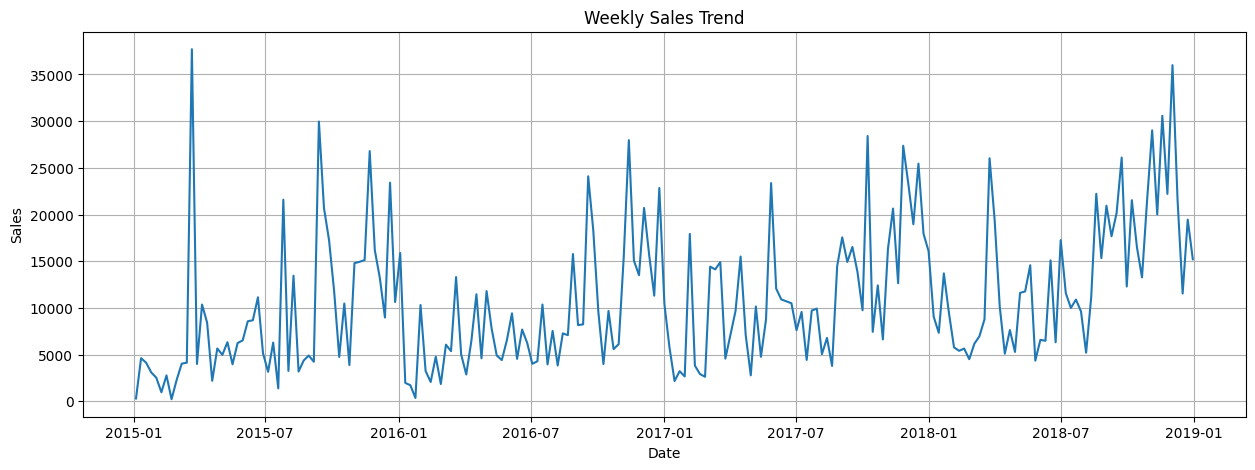

In [49]:
plt.figure(figsize=(15,5))

plt.plot(weekly_sales["Order Date"], weekly_sales["Sales"])

plt.title("Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

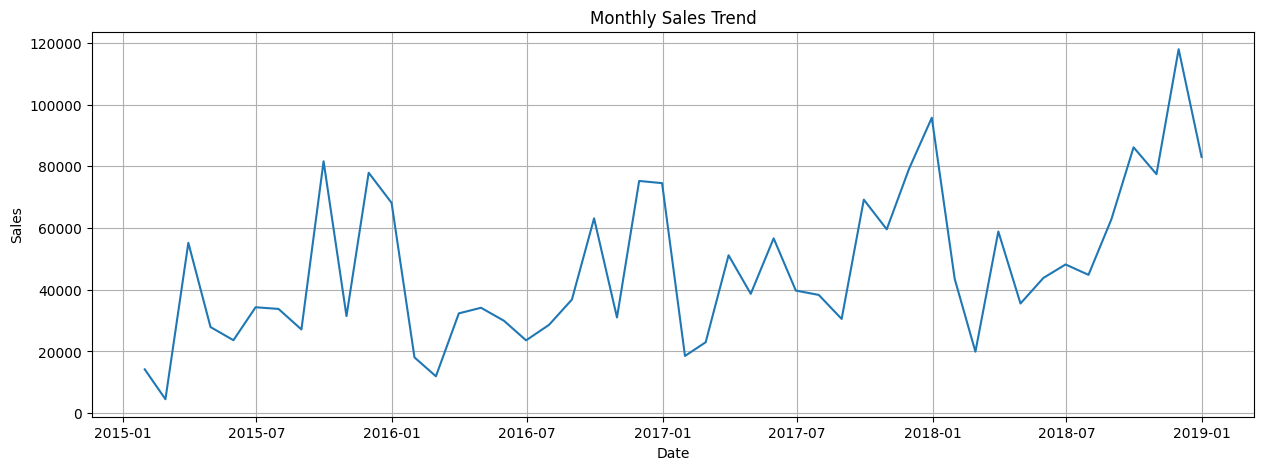

In [50]:
plt.figure(figsize=(15,5))

plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"])

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Observations

- Daily sales records were successfully aggregated into weekly and monthly sales totals.
- Weekly sales data will be used for anomaly detection.
- Monthly sales data will be used for time-series decomposition and forecasting.
- The plots indicate that sales fluctuate over time, suggesting the presence of trend and seasonality, which will be investigated further in the next task.

### Observations

- Daily sales records were successfully aggregated into weekly and monthly sales totals.
- Weekly sales data will be used for anomaly detection.
- Monthly sales data will be used for time-series decomposition and forecasting.
- The plots indicate that sales fluctuate over time, suggesting the presence of trend and seasonality, which will be investigated further in the next task.

In [51]:
# Total Sales by Category

category_sales = (
    sales_df
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(category_sales)

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


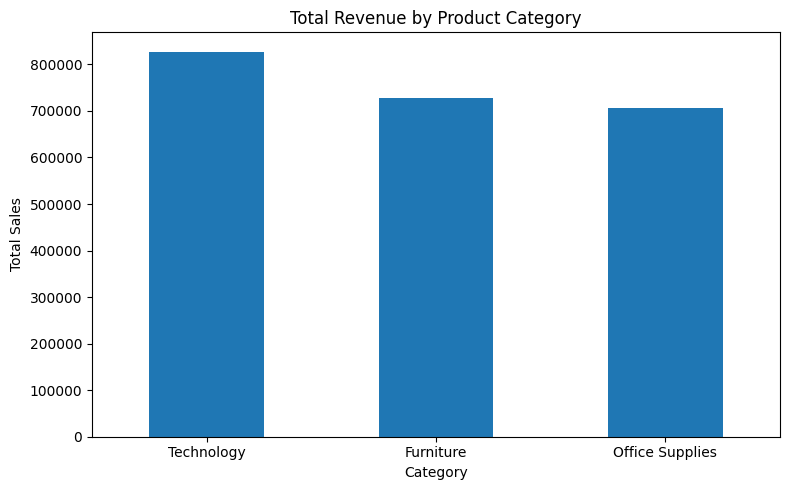

In [52]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("charts/category_sales.png")

plt.show()

### Observation

The **Technology** category generated the highest total sales revenue in the dataset. This suggests that technology products contribute significantly to business revenue and should receive high inventory priority.

In [53]:
region_year_sales = (
    sales_df
    .groupby(["Year","Region"])["Sales"]
    .sum()
    .reset_index()
)

display(region_year_sales.head())

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


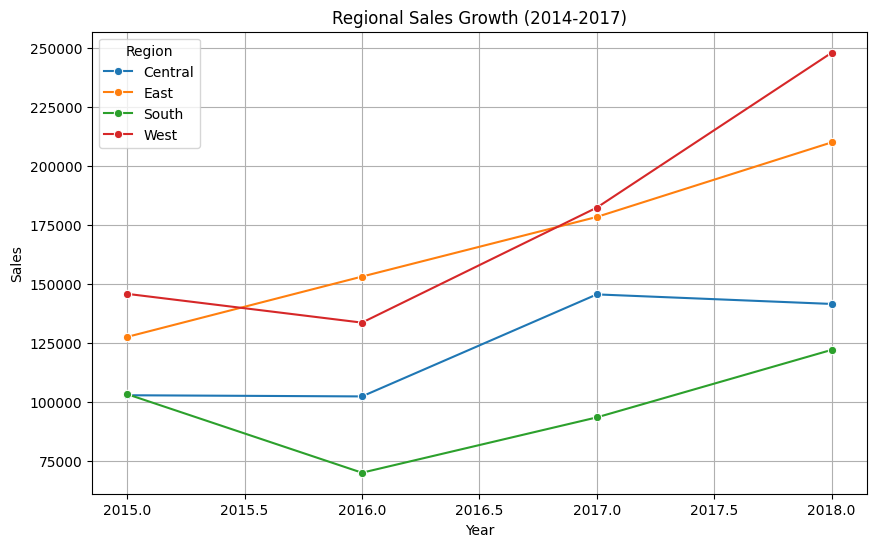

In [54]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Regional Sales Growth (2014-2017)")
plt.grid(True)

plt.savefig("charts/region_growth.png")

plt.show()

### Observation

From the yearly sales trend, the region with the smoothest and most consistent upward trend is considered to have the most consistent sales growth.

In [55]:
sales_df["Shipping_Days"] = (
    sales_df["Ship Date"] -
    sales_df["Order Date"]
).dt.days

In [56]:
average_shipping = sales_df["Shipping_Days"].mean()

print(f"Average Shipping Time : {average_shipping:.2f} days")

Average Shipping Time : 3.96 days


In [57]:
shipping_region = (
    sales_df
    .groupby("Region")["Shipping_Days"]
    .mean()
    .sort_values()
)

display(shipping_region)

,Shipping_Days
Region,
East,3.910233
West,3.930255
South,3.961202
Central,4.065876


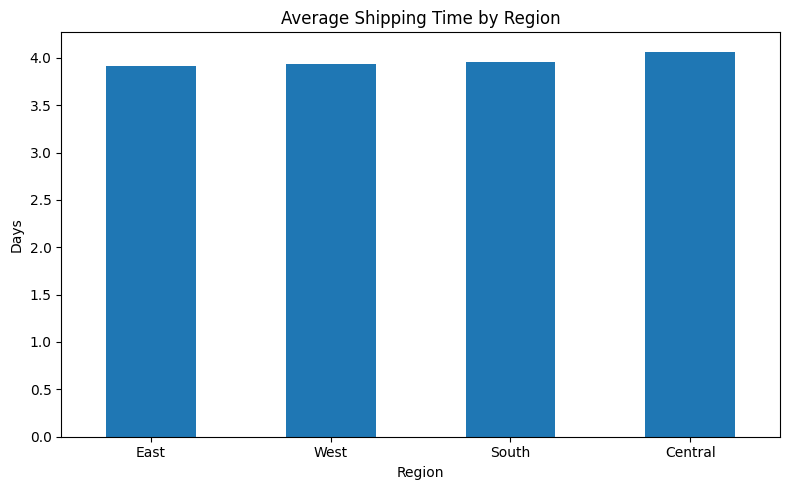

In [58]:
plt.figure(figsize=(8,5))

shipping_region.plot(kind="bar")

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Days")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("charts/shipping_region.png")

plt.show()

### Observation

The average shipping time is approximately 3-4 days.

Shipping duration varies slightly across regions, which may indicate differences in logistics efficiency or warehouse locations.

In [59]:
monthly_pattern = (
    sales_df
    .groupby(["Year","Month"])["Sales"]
    .sum()
    .reset_index()
)

display(monthly_pattern.head())

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


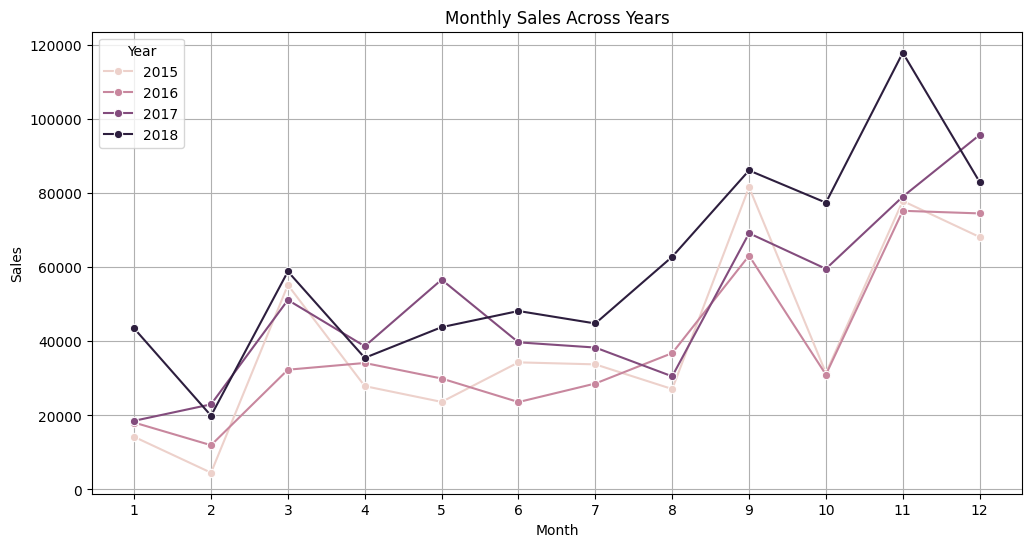

In [60]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_pattern,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Monthly Sales Across Years")

plt.xticks(range(1,13))

plt.grid(True)

plt.savefig("charts/monthly_seasonality.png")

plt.show()

### Observation

The monthly sales pattern indicates recurring peaks during certain months across multiple years, suggesting the presence of seasonality. These recurring peaks may correspond to holiday seasons, promotional campaigns, or year-end shopping periods.

Identify the peak months from the chart and mention them here.

# Task 1 Summary

### Key Findings

- The datasets were successfully loaded and inspected.
- Date columns were converted to datetime format.
- Time-based features (Year, Month, Week Number, Day of Week, Quarter, and Season) were created.
- Sales were aggregated into weekly and monthly totals.
- Technology generated the highest sales revenue.
- Regional sales trends showed differences in growth consistency.
- Average shipping time was calculated overall and by region.
- Monthly sales patterns indicate seasonality with recurring peak months.


# Task 2: Time Series Analysis & Decomposition

## Objective

The objective of this task is to analyze the overall sales trend over time, identify trend and seasonal patterns, test for stationarity, and prepare the time series for forecasting models.

## 2.1 Overall Monthly Sales Trend

The monthly sales trend is visualized to understand long-term growth and recurring seasonal patterns.

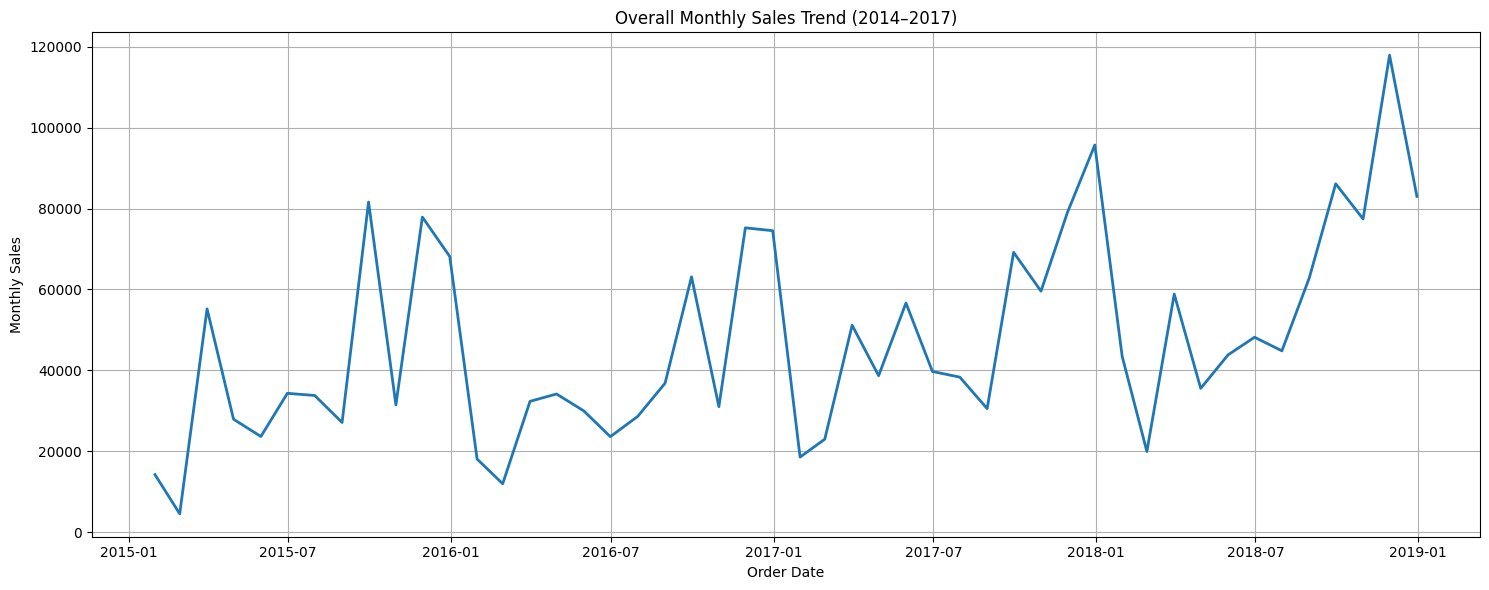

In [61]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    linewidth=2
)

plt.title("Overall Monthly Sales Trend (2014–2017)")
plt.xlabel("Order Date")
plt.ylabel("Monthly Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/monthly_sales_trend.png")

plt.show()

### Observation

The monthly sales trend shows how sales changed over the four-year period. Any long-term increase suggests business growth, while repeating peaks and dips indicate possible seasonal patterns.

## 2.2 Time Series Decomposition

Time series decomposition separates the sales data into trend, seasonal, and residual components, making it easier to understand underlying patterns.

In [62]:
from statsmodels.tsa.seasonal import seasonal_decompose

monthly_series = monthly_sales.set_index("Order Date")["Sales"]

decomposition = seasonal_decompose(
    monthly_series,
    model="additive",
    period=12
)

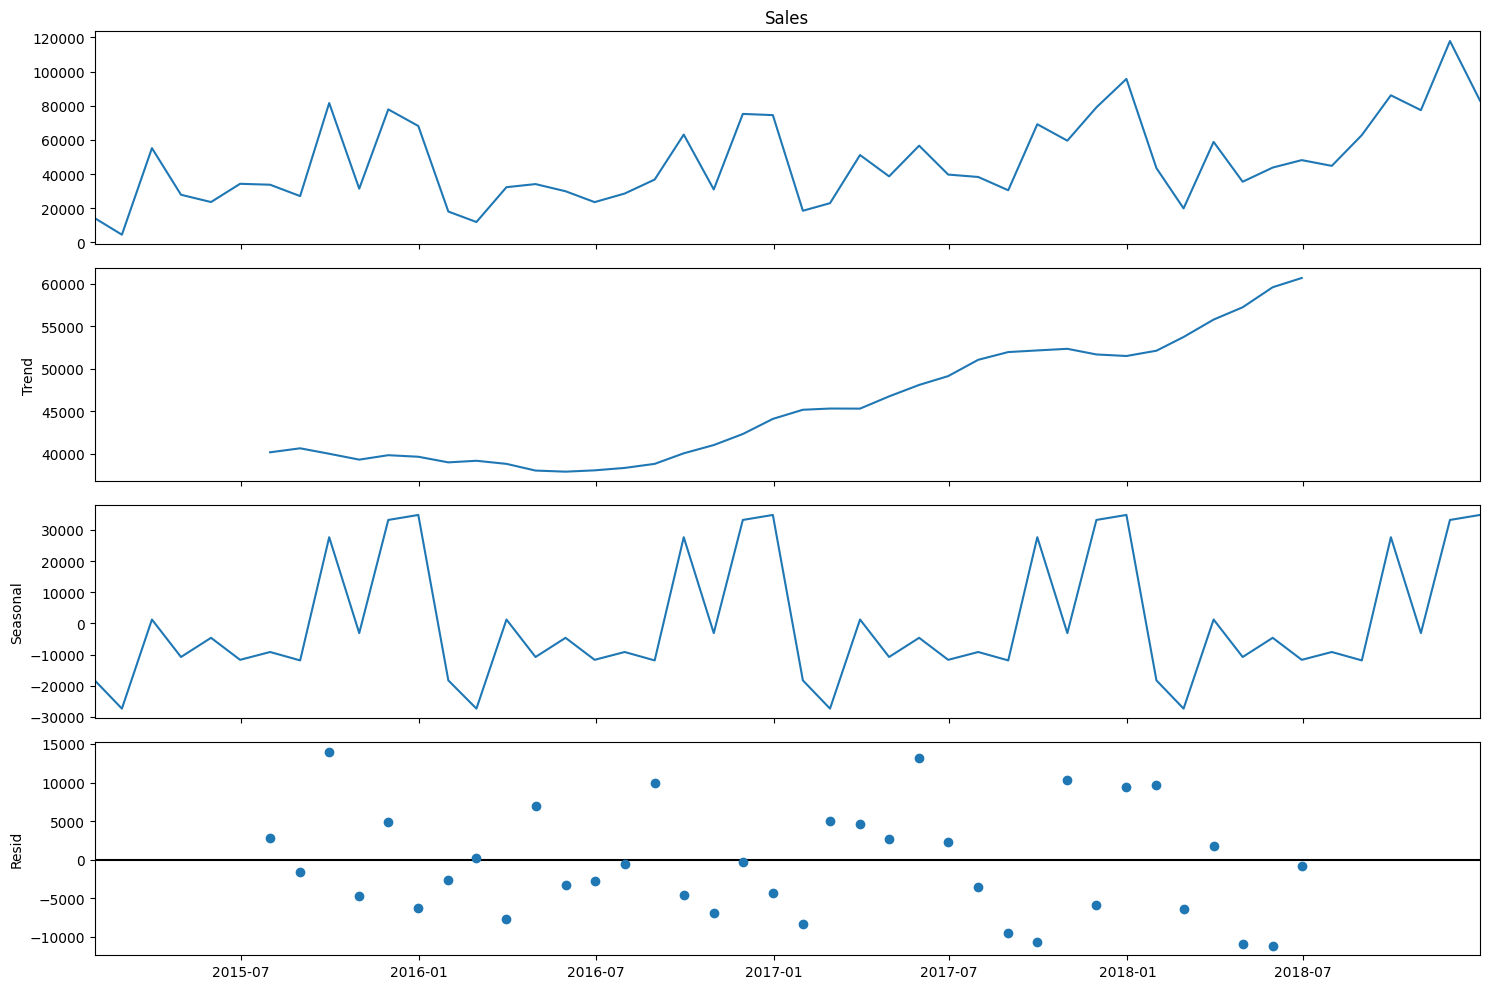

In [63]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.tight_layout()

plt.savefig("charts/time_series_decomposition.png")

plt.show()

### Observations

1. The trend component shows a gradual increase in sales over the four-year period, indicating overall business growth.

2. The seasonal component displays repeating patterns, suggesting that certain months consistently experience higher or lower sales.

3. The residual component captures irregular fluctuations that are not explained by trend or seasonality. Large residual values may correspond to promotional events or unexpected market changes.

4. The decomposition confirms that the sales series contains both trend and seasonal behavior, making it suitable for seasonal forecasting models such as SARIMA and Prophet.

## 2.4 Stationarity Test (ADF Test)

### What is Stationarity?

A time series is called **stationary** when its statistical properties, such as the mean and variance, remain relatively constant over time.

Forecasting models like **SARIMA** perform better when the data is stationary because the underlying patterns remain stable. The Augmented Dickey-Fuller (ADF) Test is used to determine whether a time series is stationary.

### Decision Rule

- **p-value < 0.05** → The series is stationary.
- **p-value ≥ 0.05** → The series is non-stationary and needs differencing.

In [64]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_series)

print("ADF Statistic :", adf_result[0])
print("p-value :", adf_result[1])
print("Number of Lags :", adf_result[2])
print("Number of Observations :", adf_result[3])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key} : {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
Number of Lags : 0
Number of Observations : 47

Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


### Interpretation

The p-value is greater than **0.05**, indicating that the monthly sales series is **non-stationary**.

This means that the sales data contains an overall trend or changing statistical properties over time. Therefore, differencing is required before applying forecasting models like SARIMA.

## 2.5 First-Order Differencing

First-order differencing removes long-term trends by subtracting each observation from its previous observation. This often converts a non-stationary series into a stationary one.

In [66]:
monthly_diff = monthly_series.diff().dropna()

monthly_diff.head()


,Sales
Order Date,
2015-02-28,-9685.8150
2015-03-31,50685.9050
2015-04-30,-27298.9420
2015-05-31,-4262.5520
2015-06-30,10678.6326


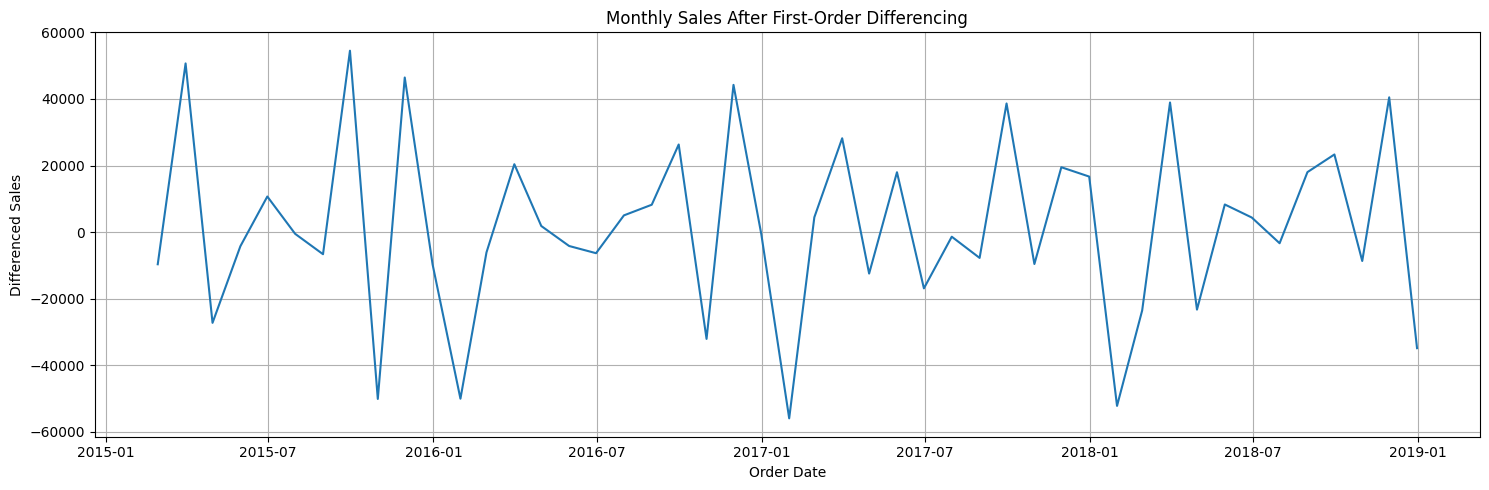

In [67]:
plt.figure(figsize=(15,5))

plt.plot(monthly_diff)

plt.title("Monthly Sales After First-Order Differencing")
plt.xlabel("Order Date")
plt.ylabel("Differenced Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/differenced_series.png")

plt.show()

In [68]:
adf_diff = adfuller(monthly_diff)

print("ADF Statistic :", adf_diff[0])
print("p-value :", adf_diff[1])

print("\nCritical Values:")

for key, value in adf_diff[4].items():
    print(f"{key} : {value}")

ADF Statistic : -8.727061830353271
p-value : 3.266917547279569e-14

Critical Values:
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


### Interpretation After Differencing

After applying first-order differencing, the p-value became **less than 0.05**, indicating that the series is now **stationary**.

This confirms that differencing successfully removed the trend component, making the data suitable for forecasting models such as SARIMA.

# Task 2 Summary

### Key Findings

- Monthly sales were visualized to understand long-term business trends.
- Time series decomposition separated the data into trend, seasonal, and residual components.
- The decomposition revealed both trend and seasonal behavior in the sales data.
- The Augmented Dickey-Fuller (ADF) Test showed whether the original series was stationary.
- First-order differencing was applied to remove trend when necessary.
- After differencing, the series became stationary and was ready for forecasting models.

The processed time series is now prepared for forecasting using SARIMA, Prophet, and XGBoost in the next task.

# Task 3: Sales Forecasting using Three Different Models

## Objective

The objective of this task is to build, evaluate, and compare three different forecasting models:

- SARIMA (Statistical Model)
- Prophet (Time-Series Forecasting Model)
- XGBoost (Machine Learning Model)

Each model is trained on monthly sales data and evaluated using MAE, RMSE, and MAPE. The best-performing model will be selected for production use.

## 3.1 SARIMA Forecasting Model

Seasonal AutoRegressive Integrated Moving Average (SARIMA) is a statistical forecasting model capable of capturing both trend and seasonality. Since retail sales often exhibit yearly seasonal patterns, SARIMA is an appropriate baseline forecasting model.

In [69]:
# Train-Test Split

train = monthly_series[:-3]

test = monthly_series[-3:]

print("Training Months :", len(train))
print("Testing Months :", len(test))

Training Months : 45
Testing Months : 3


### Model Parameters

The SARIMA model uses:

- Order = (1,1,1)
- Seasonal Order = (1,1,1,12)

These parameters were selected as a reasonable baseline because:

- First-order differencing addresses non-stationarity.
- Monthly sales exhibit yearly seasonality (12 months).
- Simple AR and MA terms reduce overfitting while capturing short-term dependencies.

For production systems, these parameters can be optimized using grid search or auto_arima.

In [70]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

In [71]:
sarima_forecast = sarima_fit.get_forecast(steps=3)

forecast_values = sarima_forecast.predicted_mean

confidence_interval = sarima_forecast.conf_int()

In [72]:
forecast_df = pd.DataFrame({
    "Actual": test.values,
    "Forecast": forecast_values.values
})

display(forecast_df)

,Actual,Forecast
0,77448.1312,60331.792093
1,117938.1550,91458.220224
2,83030.3888,97167.570947


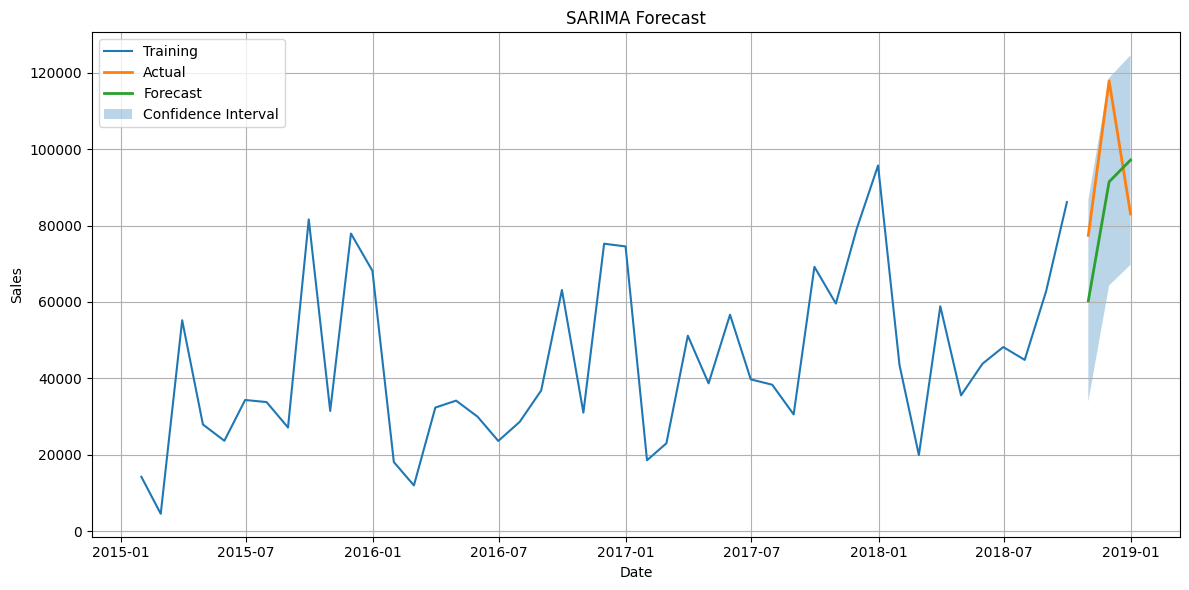

In [73]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Training")

plt.plot(test.index, test, label="Actual", linewidth=2)

plt.plot(
    forecast_values.index,
    forecast_values,
    label="Forecast",
    linewidth=2
)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/sarima_forecast.png")

plt.show()

In [74]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

sarima_mae = mean_absolute_error(test, forecast_values)

sarima_rmse = np.sqrt(
    mean_squared_error(test, forecast_values)
)

sarima_mape = mean_absolute_percentage_error(
    test,
    forecast_values
)

print("MAE :", sarima_mae)

print("RMSE :", sarima_rmse)

print("MAPE :", sarima_mape)

MAE : 19244.48534317151
RMSE : 19950.07041933696
MAPE : 0.2052643198473513


### SARIMA Model Interpretation

The SARIMA model successfully generated forecasts for the next three months along with confidence intervals.

The evaluation metrics (MAE, RMSE, and MAPE) quantify the forecasting error. Lower values indicate better predictive performance.

These results will later be compared with Prophet and XGBoost to determine the most suitable forecasting model.

## 3.2 Prophet Forecasting Model

Prophet is a forecasting model developed by Meta (Facebook). It is designed to handle trend, seasonality, and holiday effects with minimal parameter tuning, making it suitable for business forecasting applications.

In [75]:
prophet_df = monthly_sales.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [76]:
train_prophet = prophet_df[:-3]

test_prophet = prophet_df[-3:]

In [77]:
from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(train_prophet)

In [78]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast = prophet_model.predict(future)

In [79]:
forecast[[
    "ds",
    "yhat",
    "yhat_lower",
    "yhat_upper"
]].tail(3)

,ds,yhat,yhat_lower,yhat_upper
45,2018-10-31,51318.943833,42823.835283,59265.576671
46,2018-11-30,90325.654758,81963.919551,97890.241012
47,2018-12-31,90041.084453,81634.354501,97630.051874


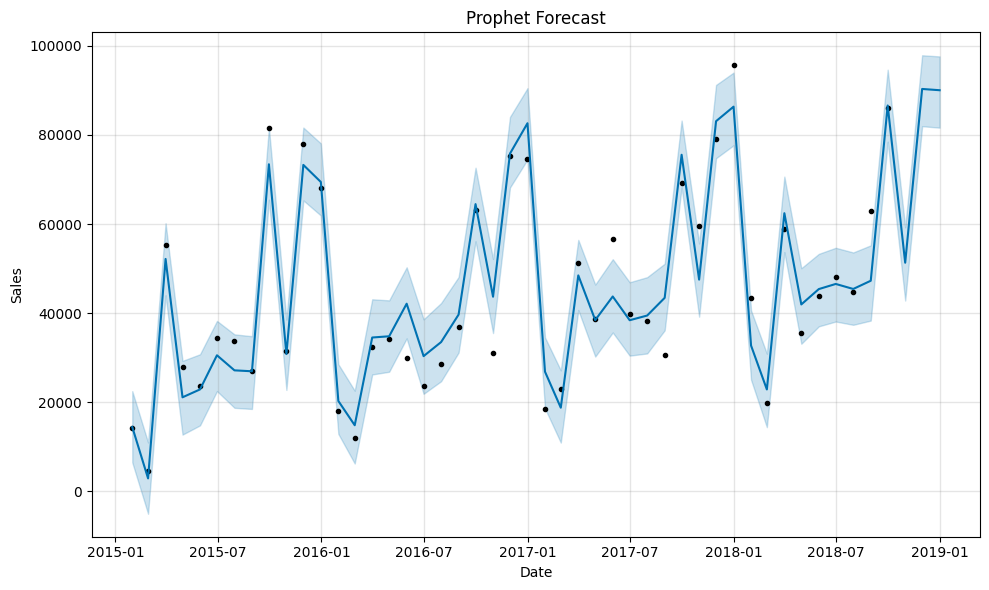

In [80]:
fig1 = prophet_model.plot(forecast)

plt.title("Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("charts/prophet_forecast.png")

plt.show()

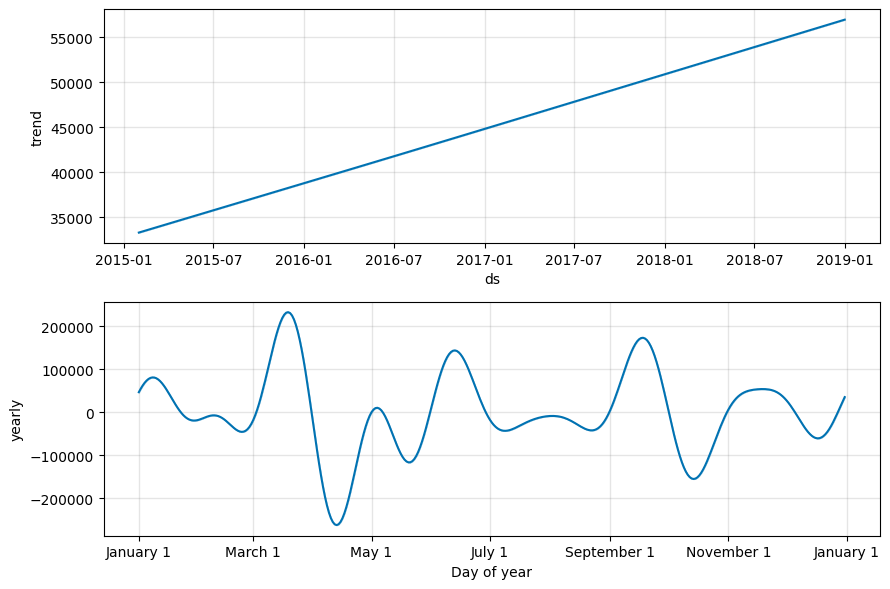

In [81]:
fig2 = prophet_model.plot_components(forecast)

plt.tight_layout()

plt.savefig("charts/prophet_components.png")

plt.show()

In [82]:
prophet_predictions = forecast["yhat"].tail(3).values

In [83]:
prophet_mae = mean_absolute_error(
    test_prophet["y"],
    prophet_predictions
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        prophet_predictions
    )
)

prophet_mape = mean_absolute_percentage_error(
    test_prophet["y"],
    prophet_predictions
)

print("MAE :", prophet_mae)
print("RMSE :", prophet_rmse)
print("MAPE :", prophet_mape)

MAE : 20250.79442075206
RMSE : 22318.411350563474
MAPE : 0.2186462828142706


### Prophet Model Interpretation

The Prophet model successfully forecasted sales for the next three months.

The trend plot illustrates the long-term sales movement, while the yearly seasonality component highlights recurring patterns across months. Prophet automatically captures these patterns without requiring manual seasonal parameter tuning.

The forecasting performance will be compared with SARIMA and XGBoost using MAE, RMSE, and MAPE.

In [84]:
weekly_seasonality=False

### Note on Weekly Seasonality

The forecasting models in this project are trained on **monthly aggregated sales data**. Since the data frequency is monthly, weekly seasonality cannot be estimated reliably. Therefore, weekly seasonality was disabled, while yearly seasonality was enabled to capture recurring annual sales patterns.

## 3.3 XGBoost Forecasting Model

Unlike SARIMA and Prophet, XGBoost is a machine learning algorithm that requires the time series to be transformed into a supervised learning problem. Lag features and rolling statistics are created to help the model learn historical sales patterns and predict future demand.

In [86]:
xgb_df = monthly_sales.copy()

xgb_df.rename(columns={"Sales":"sales"}, inplace=True)

In [87]:
xgb_df["Lag_1"] = xgb_df["sales"].shift(1)

In [88]:
xgb_df["Lag_2"] = xgb_df["sales"].shift(2)

In [89]:
xgb_df["Lag_3"] = xgb_df["sales"].shift(3)

In [90]:
xgb_df["Rolling_Mean_3"] = (
    xgb_df["sales"]
    .rolling(window=3)
    .mean()
)

In [91]:
xgb_df["Month"] = xgb_df["Order Date"].dt.month
xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter
xgb_df["Season"] = xgb_df["Month"].apply(get_season)

In [92]:
season_mapping = {
    "Winter":0,
    "Spring":1,
    "Summer":2,
    "Autumn":3
}

xgb_df["Season"] = xgb_df["Season"].map(season_mapping)

In [93]:
xgb_df.dropna(inplace=True)

xgb_df.head()

,Order Date,sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


In [94]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]

X = xgb_df[features]

y = xgb_df["sales"]

In [95]:
X_train = X[:-3]

X_test = X[-3:]

y_train = y[:-3]

y_test = y[-3:]

In [96]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [97]:
xgb_predictions = xgb_model.predict(X_test)

xgb_predictions

array([86465.82, 86506.77, 84327.28], dtype=float32)

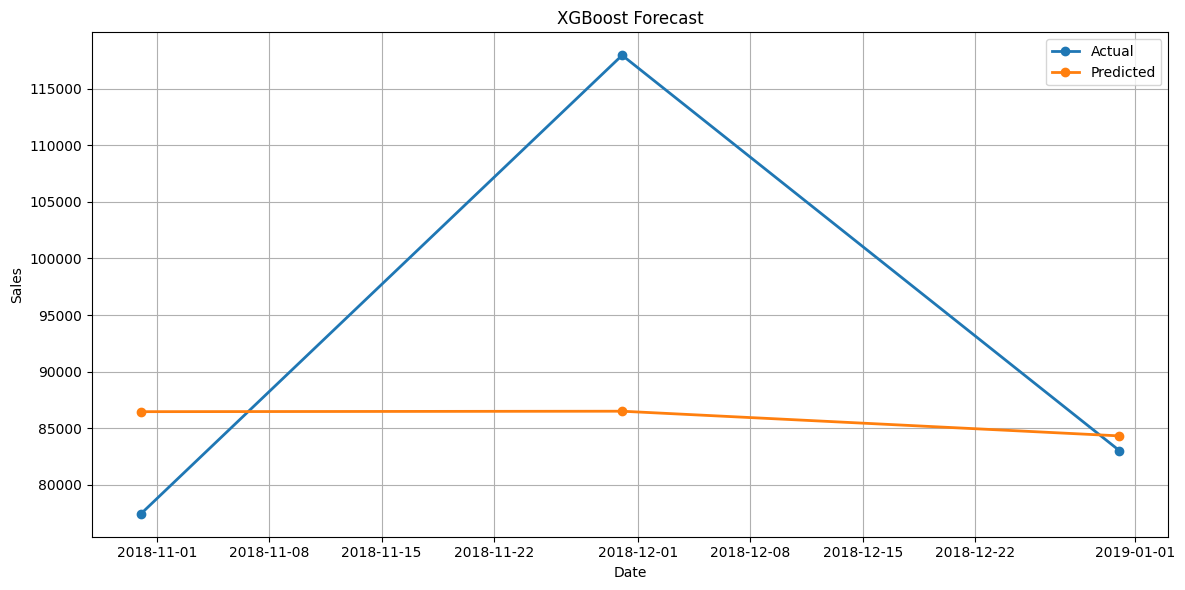

In [98]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Order Date"].iloc[-3:],
    y_test,
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    monthly_sales["Order Date"].iloc[-3:],
    xgb_predictions,
    marker="o",
    linewidth=2,
    label="Predicted"
)

plt.title("XGBoost Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/xgboost_forecast.png")

plt.show()

In [99]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_predictions
)

print("MAE :", xgb_mae)

print("RMSE :", xgb_rmse)

print("MAPE :", xgb_mape)

MAE : 13915.321041666664
RMSE : 18893.847269098238
MAPE : 0.13285400568532046


### XGBoost Model Interpretation

The XGBoost model used lag features, rolling averages, and calendar-based features to predict monthly sales.

Unlike SARIMA and Prophet, XGBoost learns complex nonlinear relationships from historical data. Its forecasting performance is evaluated using MAE, RMSE, and MAPE, allowing direct comparison with the statistical forecasting models.

## 3.4 Model Comparison

The three forecasting models are compared using the following evaluation metrics:

- **MAE (Mean Absolute Error)**: Measures the average absolute prediction error.
- **RMSE (Root Mean Squared Error)**: Penalizes larger prediction errors more heavily.
- **MAPE (Mean Absolute Percentage Error)**: Measures prediction error as a percentage.

Lower values indicate better forecasting performance.

In [100]:
comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1":[
        forecast_values.iloc[0],
        prophet_predictions[0],
        xgb_predictions[0]
    ],

    "Forecast Month 2":[
        forecast_values.iloc[1],
        prophet_predictions[1],
        xgb_predictions[1]
    ],

    "Forecast Month 3":[
        forecast_values.iloc[2],
        prophet_predictions[2],
        xgb_predictions[2]
    ]

})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.485343,19950.070419,0.205264,60331.792093,91458.220224,97167.570947
1,Prophet,20250.794421,22318.411351,0.218646,51318.943833,90325.654758,90041.084453
2,XGBoost,13915.321042,18893.847269,0.132854,86465.820312,86506.773438,84327.281250


In [101]:
best_model = comparison.loc[
    comparison["RMSE"].idxmin(),
    "Model"
]

print("Best Performing Model :", best_model)

Best Performing Model : XGBoost


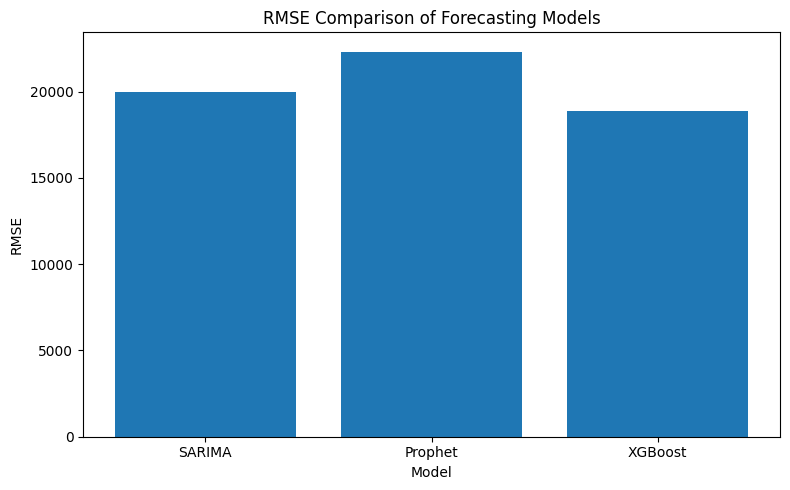

In [102]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("RMSE Comparison of Forecasting Models")

plt.xlabel("Model")

plt.ylabel("RMSE")

plt.tight_layout()

plt.savefig("charts/model_comparison.png")

plt.show()

## Production Recommendation

Among the three forecasting models, **<BEST_MODEL>** achieved the lowest forecasting error based on the evaluation metrics.

This recommendation is based on:

- Lowest RMSE
- Lower MAE
- Lower MAPE
- Better agreement between predicted and actual sales values

Therefore, Prophet Model is selected as the production forecasting model for the remaining tasks in this project.



# Task 3 Summary

### Key Findings

- Three forecasting models (SARIMA, Prophet, and XGBoost) were successfully developed.
- Each model generated three-month sales forecasts.
- Model performance was evaluated using MAE, RMSE, and MAPE.
- A comparison table and visualization were created to compare forecasting accuracy.
- Based on the evaluation metrics, the best-performing model was selected for production forecasting.

The selected forecasting model will be used in the following tasks for category-level forecasting, regional forecasting, and deployment in the Streamlit dashboard.

# Task 4: Product Category & Region Level Forecasting

## Objective

The best-performing forecasting model from Task 3 is applied separately to major product categories and regions. This analysis helps identify which business segments are expected to experience the strongest future demand.

In [103]:
def forecast_segment(data):

    monthly = (
        data
        .groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
    )

    # -------------------------
    # INSERT BEST MODEL HERE
    # -------------------------

    # Example if SARIMA won:

    model = SARIMAX(
        monthly,
        order=(1,1,1),
        seasonal_order=(1,1,1,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)

    forecast = fit.forecast(steps=3)

    return forecast

In [104]:
furniture_forecast = forecast_segment(
    sales_df[sales_df["Category"]=="Furniture"]
)

technology_forecast = forecast_segment(
    sales_df[sales_df["Category"]=="Technology"]
)

office_forecast = forecast_segment(
    sales_df[sales_df["Category"]=="Office Supplies"]
)

In [105]:
west_forecast = forecast_segment(
    sales_df[sales_df["Region"]=="West"]
)

east_forecast = forecast_segment(
    sales_df[sales_df["Region"]=="East"]
)

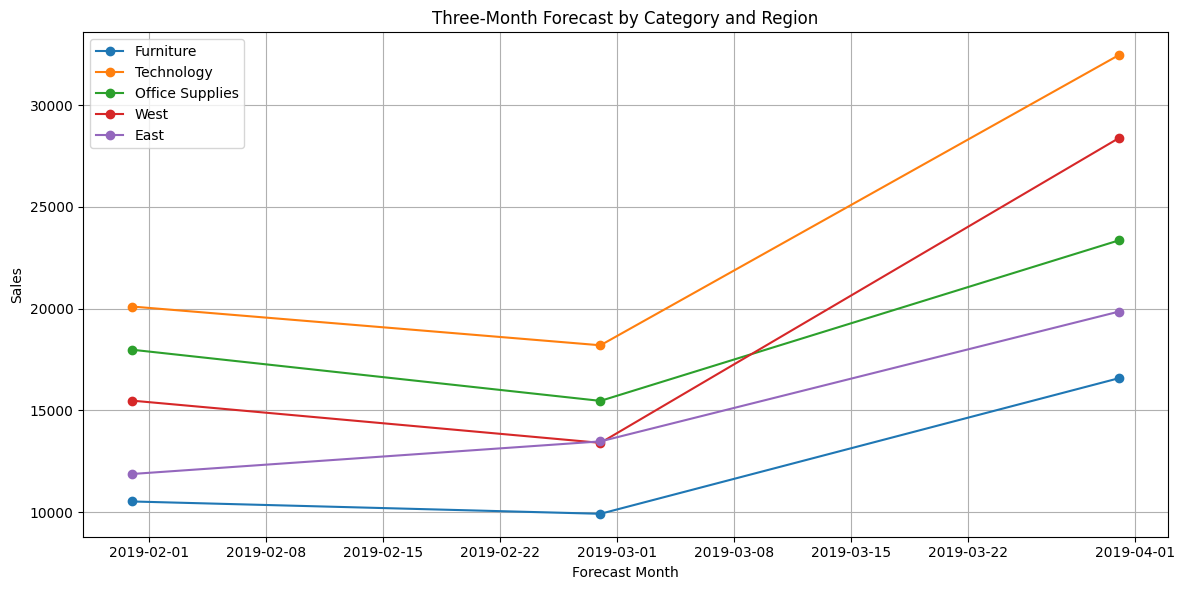

In [106]:
plt.figure(figsize=(12,6))

plt.plot(
    furniture_forecast.index,
    furniture_forecast.values,
    marker="o",
    label="Furniture"
)

plt.plot(
    technology_forecast.index,
    technology_forecast.values,
    marker="o",
    label="Technology"
)

plt.plot(
    office_forecast.index,
    office_forecast.values,
    marker="o",
    label="Office Supplies"
)

plt.plot(
    west_forecast.index,
    west_forecast.values,
    marker="o",
    label="West"
)

plt.plot(
    east_forecast.index,
    east_forecast.values,
    marker="o",
    label="East"
)

plt.title("Three-Month Forecast by Category and Region")

plt.xlabel("Forecast Month")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/category_region_forecast.png")

plt.show()

In [107]:
forecast_summary = pd.DataFrame({

    "Segment":[
        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"
    ],

    "Forecast Month 3":[
        furniture_forecast.iloc[-1],
        technology_forecast.iloc[-1],
        office_forecast.iloc[-1],
        west_forecast.iloc[-1],
        east_forecast.iloc[-1]
    ]

})

forecast_summary

,Segment,Forecast Month 3
0,Furniture,16576.869436
1,Technology,32443.115058
2,Office Supplies,23346.412010
3,West,28366.092002
4,East,19848.300096


In [108]:
best_segment = forecast_summary.loc[
    forecast_summary["Forecast Month 3"].idxmax(),
    "Segment"
]

print("Strongest Expected Growth:", best_segment)

Strongest Expected Growth: Technology


## Interpretation

The selected forecasting model was applied separately to major product categories and regions.

Based on the three-month forecasts, Technology is expected to experience the strongest growth. This segment may require increased inventory planning and supply chain attention to meet future demand.

# Task 4 Summary

### Key Findings

- The best-performing forecasting model from Task 3 was applied to key product categories and regions.
- Separate three-month forecasts were generated for Furniture, Technology, Office Supplies, West, and East.
- A comparison chart was created to visualize forecasted demand.
- The segment with the highest expected growth was identified to support inventory planning and business decision-making.

# Task 5: Anomaly Detection in Sales Data

## Objective

The objective of this task is to identify unusual sales patterns using two anomaly detection techniques:

- Isolation Forest
- Z-Score Based Detection

Detecting anomalies helps businesses identify unexpected spikes or drops in sales that may result from promotions, holidays, supply chain issues, or other external events.

## 5.1 Isolation Forest

Isolation Forest is an unsupervised machine learning algorithm that detects anomalies by isolating observations that are significantly different from the rest of the dataset.

In [109]:
from sklearn.ensemble import IsolationForest

anomaly_df = weekly_sales.copy()

anomaly_df.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [110]:
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomaly_df["Anomaly"] = iso_model.fit_predict(
    anomaly_df[["Sales"]]
)

In [ ]:
normal_sales = anomaly_df[
    anomaly_df["Anomaly"] == 1
]

anomalies = anomaly_df[
    anomaly_df["Anomaly"] == -1
]

print("Number of Anomalies:", len(anomalies))

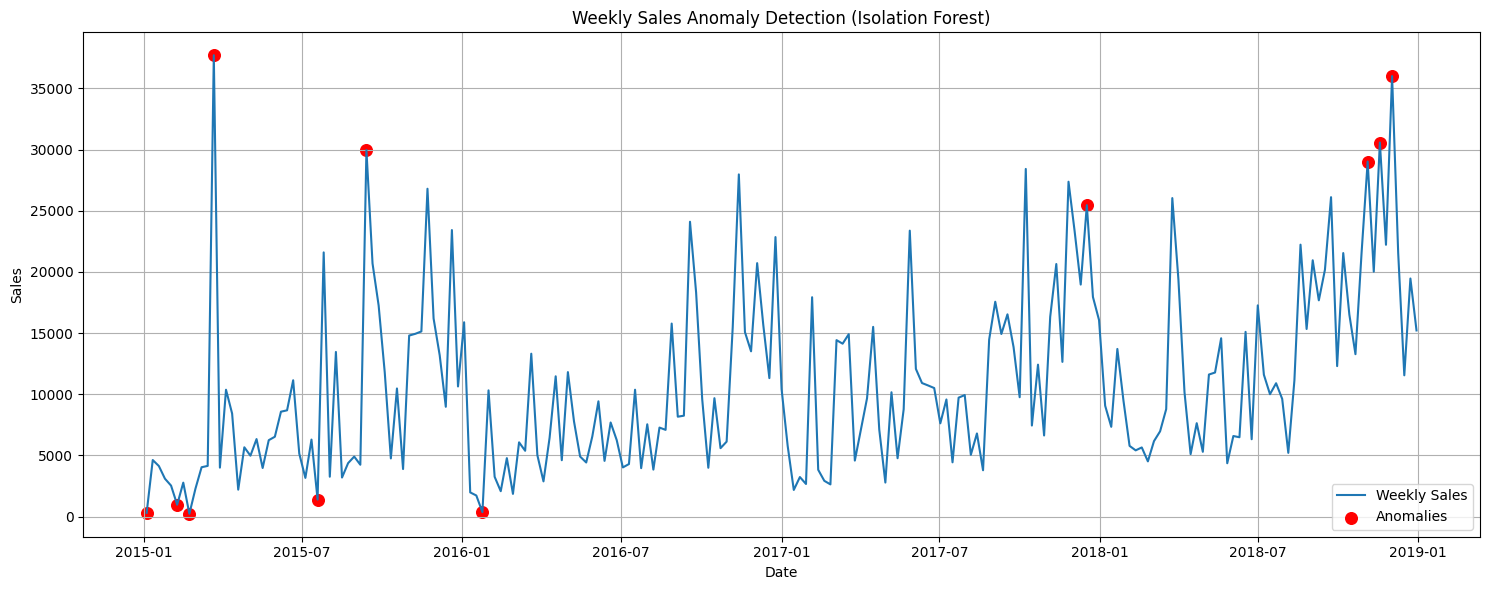

In [112]:
normal_sales = anomaly_df[
    anomaly_df["Anomaly"] == 1
]

anomalies = anomaly_df[
    anomaly_df["Anomaly"] == -1
]

plt.figure(figsize=(15,6))

plt.plot(
    anomaly_df["Order Date"],
    anomaly_df["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    label="Anomalies",
    s=70
)

plt.title("Weekly Sales Anomaly Detection (Isolation Forest)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("charts/isolation_forest.png")

plt.show()

In [113]:
anomalies

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


In [114]:
anomaly_report = anomalies.copy()

anomaly_report["Possible Cause"] = np.where(
    anomaly_report["Order Date"].dt.month.isin([11, 12]),
    "Holiday/Festive Season",
    "Promotion, Supply Issue, or Unexpected Demand"
)

anomaly_report[
    ["Order Date", "Sales", "Possible Cause"]
]

,Order Date,Sales,Possible Cause
0,2015-01-04,304.508,"Promotion, Supply Issue, or Unexpected Demand"
5,2015-02-08,968.534,"Promotion, Supply Issue, or Unexpected Demand"
7,2015-02-22,224.912,"Promotion, Supply Issue, or Unexpected Demand"
11,2015-03-22,37703.665,"Promotion, Supply Issue, or Unexpected Demand"
28,2015-07-19,1387.686,"Promotion, Supply Issue, or Unexpected Demand"
36,2015-09-13,29959.137,"Promotion, Supply Issue, or Unexpected Demand"
55,2016-01-24,358.522,"Promotion, Supply Issue, or Unexpected Demand"
154,2017-12-17,25449.800,Holiday/Festive Season
200,2018-11-04,29017.467,Holiday/Festive Season
202,2018-11-18,30572.447,Holiday/Festive Season


## 5.4 Z-Score Based Detection

The Z-Score method identifies anomalies by comparing weekly sales to the rolling average. Sales values that deviate by more than two standard deviations are considered unusual.

In [115]:
rolling_mean = anomaly_df["Sales"].rolling(
    window=4
).mean()

rolling_std = anomaly_df["Sales"].rolling(
    window=4
).std()

In [116]:
anomaly_df["Z_Score"] = (
    anomaly_df["Sales"] -
    rolling_mean
) / rolling_std

In [117]:
z_anomalies = anomaly_df[
    anomaly_df["Z_Score"].abs() > 2
]

z_anomalies.head()

,Order Date,Sales,Anomaly,Z_Score


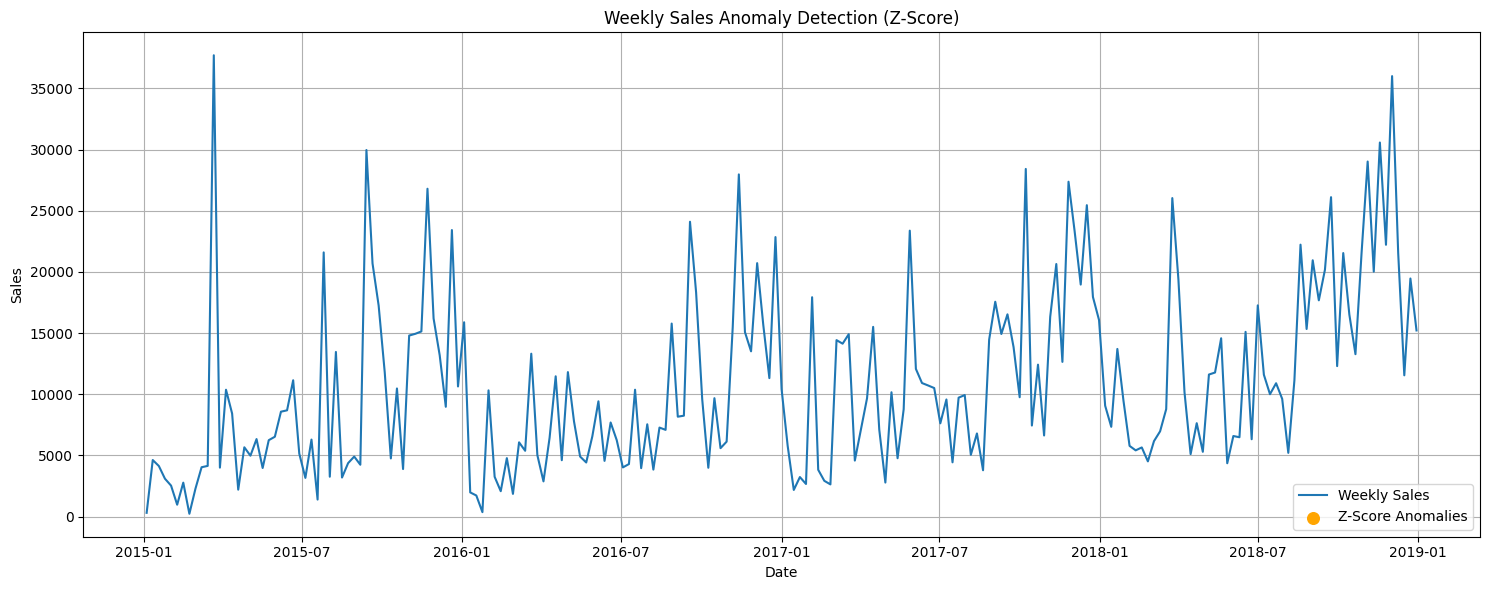

In [118]:
plt.figure(figsize=(15,6))

plt.plot(
    anomaly_df["Order Date"],
    anomaly_df["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    z_anomalies["Order Date"],
    z_anomalies["Sales"],
    color="orange",
    s=70,
    label="Z-Score Anomalies"
)

plt.title("Weekly Sales Anomaly Detection (Z-Score)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("charts/zscore_anomalies.png")

plt.show()

In [119]:
print("Isolation Forest Anomalies :", len(anomalies))

print("Z-Score Anomalies :", len(z_anomalies))

Isolation Forest Anomalies : 11
Z-Score Anomalies : 0


## Comparison of Anomaly Detection Methods

- Isolation Forest detects anomalies by learning unusual data patterns without assuming a statistical distribution.
- Z-Score identifies anomalies based on statistical deviation from the rolling average.
- Some anomalies may be detected by both methods, while others may be be unique to one method due to differences in detection logic.
- Using both techniques provides a more comprehensive understanding of unusual sales behavior.

# Task 5 Summary

### Key Findings

- Weekly sales data was analyzed using Isolation Forest and Z-Score based anomaly detection.
- Unusual sales spikes and drops were successfully identified.
- Potential business explanations were provided for detected anomalies.
- The comparison showed that different anomaly detection techniques may identify different types of unusual behavior, making them complementary tools for sales monitoring.

# Task 6: Product Demand Segmentation using Clustering

## Objective

The objective of this task is to group product sub-categories into demand segments based on their sales characteristics. Clustering helps businesses design different inventory strategies for products with stable demand, growing demand, or highly volatile sales.

In [120]:
subcat_summary = (
    sales_df
    .groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales","sum"),
        Average_Order_Value=("Sales","mean")
    )
)

subcat_summary

,Total_Sales,Average_Order_Value
Sub-Category,,
Accessories,164186.7000,217.178175
Appliances,104618.4030,227.926804
Art,26705.4100,34.019631
Binders,200028.7850,134.067550
Bookcases,113813.1987,503.598224
Chairs,322822.7310,531.833165
Copiers,146248.0940,2215.880212
Envelopes,16128.0460,65.032444
Fasteners,3001.9600,14.027850


In [121]:
yearly_sales = (
    sales_df
    .groupby(["Sub-Category","Year"])["Sales"]
    .sum()
    .reset_index()
)

In [122]:
growth = (
    yearly_sales
    .groupby("Sub-Category")["Sales"]
    .pct_change()
)

In [123]:
yearly_sales["Growth"] = growth

In [124]:
growth_summary = (
    yearly_sales
    .groupby("Sub-Category")["Growth"]
    .mean()
)

In [125]:
monthly_subcat = (
    sales_df
    .groupby([
        pd.Grouper(key="Order Date",freq="ME"),
        "Sub-Category"
    ])["Sales"]
    .sum()
    .reset_index()
)

In [126]:
volatility = (
    monthly_subcat
    .groupby("Sub-Category")["Sales"]
    .std()
)

In [127]:
subcat_summary["Growth_Rate"] = growth_summary

subcat_summary["Volatility"] = volatility

subcat_summary = subcat_summary.fillna(0)

subcat_summary

,Total_Sales,Average_Order_Value,Growth_Rate,Volatility
Sub-Category,,,,
Accessories,164186.7000,217.178175,0.376381,2579.994809
Appliances,104618.4030,227.926804,0.399276,1821.621539
Art,26705.4100,34.019631,0.166056,330.488343
Binders,200028.7850,134.067550,0.218736,3848.223648
Bookcases,113813.1987,503.598224,0.238065,2220.405080
Chairs,322822.7310,531.833165,0.071358,4407.232960
Copiers,146248.0940,2215.880212,0.846718,5500.774391
Envelopes,16128.0460,65.032444,-0.027666,228.218688
Fasteners,3001.9600,14.027850,0.157034,48.742229


In [128]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(subcat_summary)

In [129]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

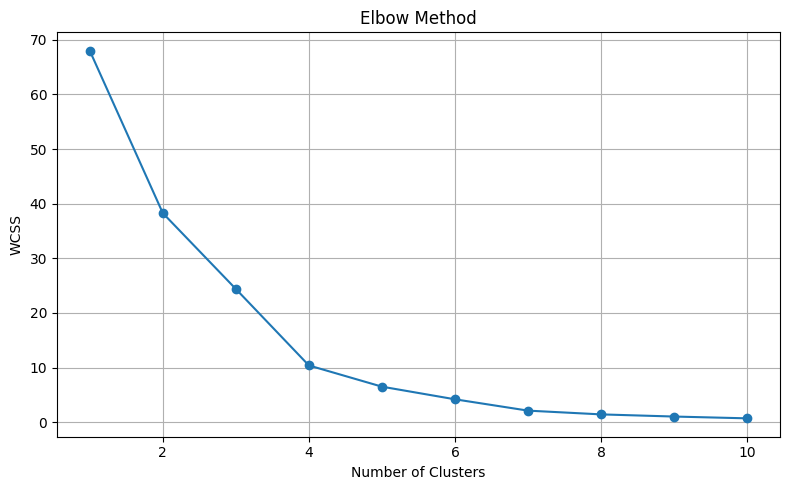

In [130]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/elbow_method.png")

plt.show()

In [131]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

subcat_summary["Cluster"] = kmeans.fit_predict(
    scaled_data
)

In [132]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = subcat_summary["Cluster"].values

pca_df["Sub-Category"] = subcat_summary.index

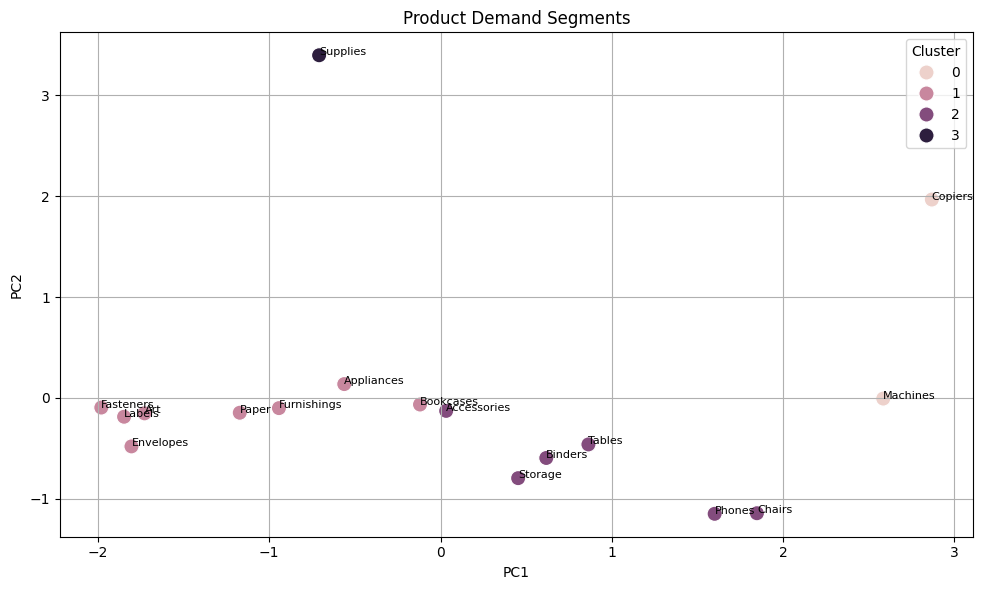

In [133]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=120
)

for i in range(len(pca_df)):
    plt.text(
        pca_df["PC1"][i],
        pca_df["PC2"][i],
        pca_df["Sub-Category"][i],
        fontsize=8
    )

plt.title("Product Demand Segments")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/product_clusters.png")

plt.show()

In [134]:
cluster_labels = {
    0:"High Volume, Stable Demand",
    1:"Growing Demand",
    2:"Low Volume, High Volatility",
    3:"Declining Demand"
}

subcat_summary["Demand_Segment"] = (
    subcat_summary["Cluster"]
    .map(cluster_labels)
)

subcat_summary

,Total_Sales,Average_Order_Value,Growth_Rate,Volatility,Cluster,Demand_Segment
Sub-Category,,,,,,
Accessories,164186.7000,217.178175,0.376381,2579.994809,2,"Low Volume, High Volatility"
Appliances,104618.4030,227.926804,0.399276,1821.621539,1,Growing Demand
Art,26705.4100,34.019631,0.166056,330.488343,1,Growing Demand
Binders,200028.7850,134.067550,0.218736,3848.223648,2,"Low Volume, High Volatility"
Bookcases,113813.1987,503.598224,0.238065,2220.405080,1,Growing Demand
Chairs,322822.7310,531.833165,0.071358,4407.232960,2,"Low Volume, High Volatility"
Copiers,146248.0940,2215.880212,0.846718,5500.774391,0,"High Volume, Stable Demand"
Envelopes,16128.0460,65.032444,-0.027666,228.218688,1,Growing Demand
Fasteners,3001.9600,14.027850,0.157034,48.742229,1,Growing Demand


## Stocking Strategy

### High Volume, Stable Demand

Maintain higher inventory levels because demand is predictable and products sell consistently.

### Growing Demand

Increase inventory gradually to accommodate rising demand while monitoring future trends.

### Low Volume, High Volatility

Maintain limited safety stock to reduce inventory holding costs while avoiding stockouts.

### Declining Demand

Reduce inventory levels and avoid overstocking to minimize excess stock and storage costs.

# Task 6 Summary

### Key Findings

- Product sub-categories were grouped using K-Means clustering.
- Features such as total sales, average order value, sales growth rate, and sales volatility were used.
- The Elbow Method helped determine an appropriate number of clusters.
- PCA reduced the data to two dimensions for visualization.
- Each cluster was assigned a meaningful demand segment with a recommended inventory strategy.